# 03 — Model Training (Undergraduate Report Version)
This notebook trains multiple regression models to predict next-day temperature and explains every step clearly. The goal is **report-ready** results that compare baselines, evaluate models fairly, and document assumptions.

## Learning objectives
- Understand time-series train/test splits and why they prevent data leakage.
- Compare baselines vs machine learning models.
- Interpret metrics ($MAE$, $RMSE$, $R^2$) and rank models.
- Perform time-series cross-validation and hyperparameter tuning.
- Visualize learning curves and error patterns.

## Outline
1. Load and prepare data
2. Build time-based train/test split
3. Baselines (persistence, climatology)
4. Train model zoo + cross-validation
5. Hyperparameter tuning (GB, RF, SVR)
6. Learning curves (bias-variance)
7. Error analysis preview
8. Save best model + metrics report

In [23]:
# Setup imports, configuration, and plotting
import json
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_validate, GridSearchCV, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import joblib
import sys

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))


DATA_PATH = Path('../data/processed/clean_weather.csv')
REPORTS_DIR = Path('../reports')
MODELS_DIR = Path('../models/saved_models')
REPORTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


## 1) Load and Prepare Data

We use the processed dataset with engineered features (lag-1 and calendar features).
Target is **next-day temperature**, so we shift `temperature_c` by -1 day.

Key rule: **never shuffle time series**. We keep temporal order to avoid leakage.

In [7]:
# Load processed data
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.sort_values('date').set_index('date')

# Build supervised target: next-day temperature
df['target_temp_next_day'] = df['temperature_c'].shift(-1)
df = df.dropna()

# Features and target
X = df.drop(columns=['target_temp_next_day'])
y = df['target_temp_next_day']

print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Date range: {X.index.min().date()} → {X.index.max().date()}")
X.head()

Dataset shape: X=(4016, 13), y=(4016,)
Date range: 2015-01-02 → 2025-12-30


,temperature_c,humidity_pct,wind_speed_mps,precipitation_mm,surface_pressure_hpa,temperature_c_lag1,humidity_pct_lag1,wind_speed_mps_lag1,precipitation_mm_lag1,surface_pressure_hpa_lag1,month,day,weekday
date,,,,,,,,,,,,,
2015-01-02 00:00:00+01:00,27.583333,66.708333,5.304167,0.0,10.008292,28.013043,53.521739,5.821739,0.0,10.001043,1,2,4
2015-01-03 00:00:00+01:00,28.266667,62.791667,5.458333,0.0,10.021000,27.583333,66.708333,5.304167,0.0,10.008292,1,3,5
2015-01-04 00:00:00+01:00,27.716667,44.041667,6.500000,0.0,10.026333,28.266667,62.791667,5.458333,0.0,10.021000,1,4,6
2015-01-05 00:00:00+01:00,26.291667,28.291667,6.079167,0.0,10.018958,27.716667,44.041667,6.500000,0.0,10.026333,1,5,0
2015-01-06 00:00:00+01:00,25.662500,33.708333,5.983333,0.0,10.011208,26.291667,28.291667,6.079167,0.0,10.018958,1,6,1


## 2) Time-Based Train/Test Split + Baselines

We split chronologically: early data for training, most recent data for testing.
This mimics real forecasting (you only use the past).

Baselines we compare against:
- **Persistence**: tomorrow = today
- **Climatology**: monthly historical average

In [8]:
# Train/test split (time-based, 80/20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

def eval_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
    }

# Baseline 1: Persistence (tomorrow = today)
persistence_pred = X_test['temperature_c'].values
baseline_persist = eval_metrics(y_test, persistence_pred)

# Baseline 2: Climatology (monthly average from training)
train_month_avg = X_train.assign(target=y_train).groupby(X_train.index.month)['target'].mean()
climatology_pred = X_test.index.month.map(train_month_avg).values
baseline_clima = eval_metrics(y_test, climatology_pred)

print("Baseline Metrics:")
print(f"  Persistence MAE: {baseline_persist['MAE']:.3f}°C")
print(f"  Climatology MAE: {baseline_clima['MAE']:.3f}°C")

Train: (3212, 13), Test: (804, 13)
Baseline Metrics:
  Persistence MAE: 0.473°C
  Climatology MAE: 0.818°C


In [9]:
# Define models (no src imports; full notebook self-contained)
def make_scaled_model(estimator):
    return Pipeline([('scaler', StandardScaler()), ('model', estimator)])

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': make_scaled_model(Ridge(alpha=1.0)),
    'Lasso': make_scaled_model(Lasso(alpha=0.01, random_state=42, max_iter=5000)),
    'DecisionTree': DecisionTreeRegressor(max_depth=6, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42),
    'SVR': make_scaled_model(SVR(C=10, gamma='scale', epsilon=0.1)),
}

tscv = TimeSeriesSplit(n_splits=5)

results = []
cv_results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    metrics = eval_metrics(y_test, preds)
    
    # Time-series CV (negative MAE, R2)
    scores = cross_validate(
        model, X_train, y_train,
        cv=tscv,
        scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'},
        n_jobs=-1
    )
    cv_mae = -scores['test_mae'].mean()
    cv_mae_std = abs(scores['test_mae'].std())
    cv_r2 = scores['test_r2'].mean()
    
    results.append({
        'Model': name,
        'MAE': metrics['MAE'],
        'RMSE': metrics['RMSE'],
        'R2': metrics['R2'],
    })
    cv_results.append({
        'Model': name,
        'CV_MAE': cv_mae,
        'CV_MAE_STD': cv_mae_std,
        'CV_R2': cv_r2,
    })

results_df = pd.DataFrame(results).sort_values('MAE')
cv_df = pd.DataFrame(cv_results).sort_values('CV_MAE')

print("Test set metrics (lower MAE is better):")
display(results_df)

print("\nTime-series CV metrics (train period only):")
display(cv_df)

Test set metrics (lower MAE is better):


,Model,MAE,RMSE,R2
2,Lasso,0.472320,0.593284,0.906381
0,LinearRegression,0.475088,0.595763,0.905598
1,Ridge,0.475110,0.595764,0.905597
4,RandomForest,0.483665,0.604964,0.902659
5,GradientBoosting,0.492827,0.612211,0.900313
3,DecisionTree,0.516313,0.666509,0.881846
6,SVR,0.549289,0.689370,0.873602



Time-series CV metrics (train period only):


,Model,CV_MAE,CV_MAE_STD,CV_R2
0,LinearRegression,0.443755,0.025215,0.875779
1,Ridge,0.443859,0.025434,0.875762
2,Lasso,0.450918,0.027055,0.873661
4,RandomForest,0.457613,0.011193,0.870946
5,GradientBoosting,0.460227,0.011893,0.868856
6,SVR,0.495381,0.030542,0.843997
3,DecisionTree,0.512783,0.025416,0.839790


## 4) Hyperparameter Tuning (TimeSeriesSplit + GridSearch)

We tune a few strong models using small grids to keep runtime reasonable.
This step often improves accuracy without overfitting.

In [10]:
# Hyperparameter grids (small but meaningful)
param_grids = {
    'GradientBoosting': {
        'n_estimators': [200, 300],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5],
    },
    'RandomForest': {
        'n_estimators': [200, 300],
        'max_depth': [6, 10],
        'min_samples_split': [2, 5],
    },
    'SVR': {
        'model__C': [5, 10],
        'model__epsilon': [0.05, 0.1],
        'model__gamma': ['scale', 'auto'],
    },
}

tuned_models = {}
tuned_results = []

for name, grid in param_grids.items():
    base_model = models[name]
    search = GridSearchCV(
        estimator=base_model,
        param_grid=grid,
        scoring='neg_mean_absolute_error',
        cv=tscv,
        n_jobs=-1
    )
    search.fit(X_train, y_train)
    tuned_models[name] = search.best_estimator_
    
    preds = search.best_estimator_.predict(X_test)
    metrics = eval_metrics(y_test, preds)
    tuned_results.append({
        'Model': name,
        'MAE': metrics['MAE'],
        'RMSE': metrics['RMSE'],
        'R2': metrics['R2'],
        'BestParams': search.best_params_,
    })
    
    print(f"{name} best params: {search.best_params_}")

tuned_df = pd.DataFrame(tuned_results).sort_values('MAE')
print("\nTuned model performance (test set):")
display(tuned_df)

GradientBoosting best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
RandomForest best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 300}
SVR best params: {'model__C': 5, 'model__epsilon': 0.1, 'model__gamma': 'scale'}

Tuned model performance (test set):


,Model,MAE,RMSE,R2,BestParams
0,GradientBoosting,0.481946,0.597950,0.904903,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."
1,RandomForest,0.488158,0.610149,0.900983,"{'max_depth': 10, 'min_samples_split': 2, 'n_e..."
2,SVR,0.534663,0.670778,0.880328,"{'model__C': 5, 'model__epsilon': 0.1, 'model_..."


## 5) Learning Curves (Bias vs Variance)

Learning curves show whether a model is underfitting or overfitting.
We plot training and validation MAE as the training set grows.

Best tuned model: GradientBoosting


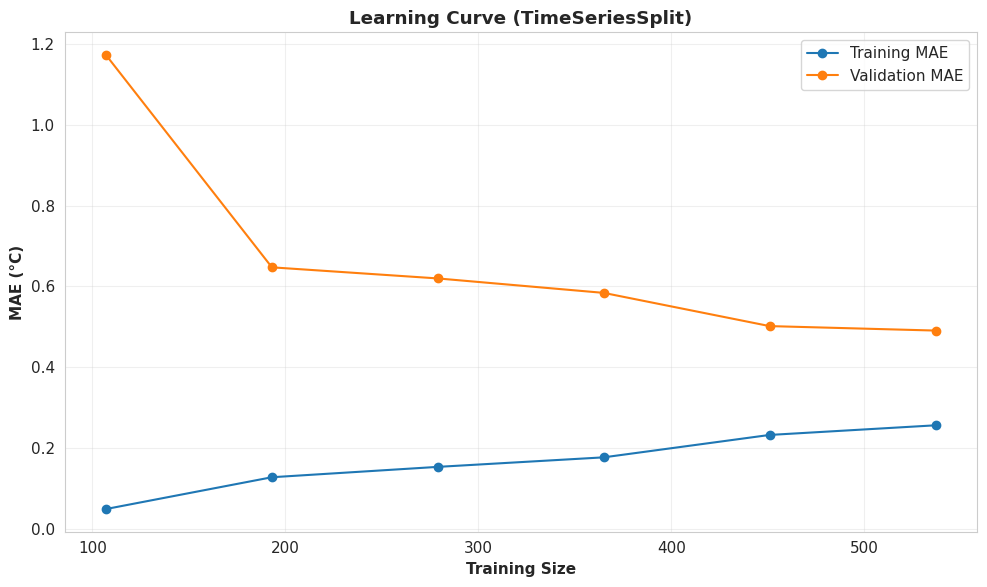

In [12]:
# Choose best tuned model by MAE
best_tuned_row = tuned_df.iloc[0]
best_model_name = best_tuned_row['Model']
best_model = tuned_models[best_model_name]

print(f"Best tuned model: {best_model_name}")

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train, y_train,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    train_sizes=np.linspace(0.2, 1.0, 6),
    n_jobs=-1
 )

train_mae = -train_scores.mean(axis=1)
val_mae = -val_scores.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mae, marker='o', label='Training MAE')
plt.plot(train_sizes, val_mae, marker='o', label='Validation MAE')
plt.xlabel('Training Size', fontweight='bold')
plt.ylabel('MAE (°C)', fontweight='bold')
plt.title('Learning Curve (TimeSeriesSplit)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../visuals/learning_curve_best_model.png', dpi=300, bbox_inches='tight')
plt.show()

## 3) Model Zoo + Time-Series Cross-Validation

We train several models and evaluate them consistently.
Cross-validation uses **TimeSeriesSplit** to respect temporal order.
This avoids information leakage and gives more reliable performance estimates.

,Model,MAE,RMSE,R2
2,Lasso,0.472320,0.593284,0.906381
0,Baseline_Persistence,0.472839,0.620297,0.897662
3,LinearRegression,0.475088,0.595763,0.905598
4,Ridge,0.475110,0.595764,0.905597
9,GradientBoosting,0.481946,0.597950,0.904903
5,RandomForest,0.483665,0.604964,0.902659
10,RandomForest,0.488158,0.610149,0.900983
6,GradientBoosting,0.492827,0.612211,0.900313
7,DecisionTree,0.516313,0.666509,0.881846
11,SVR,0.534663,0.670778,0.880328


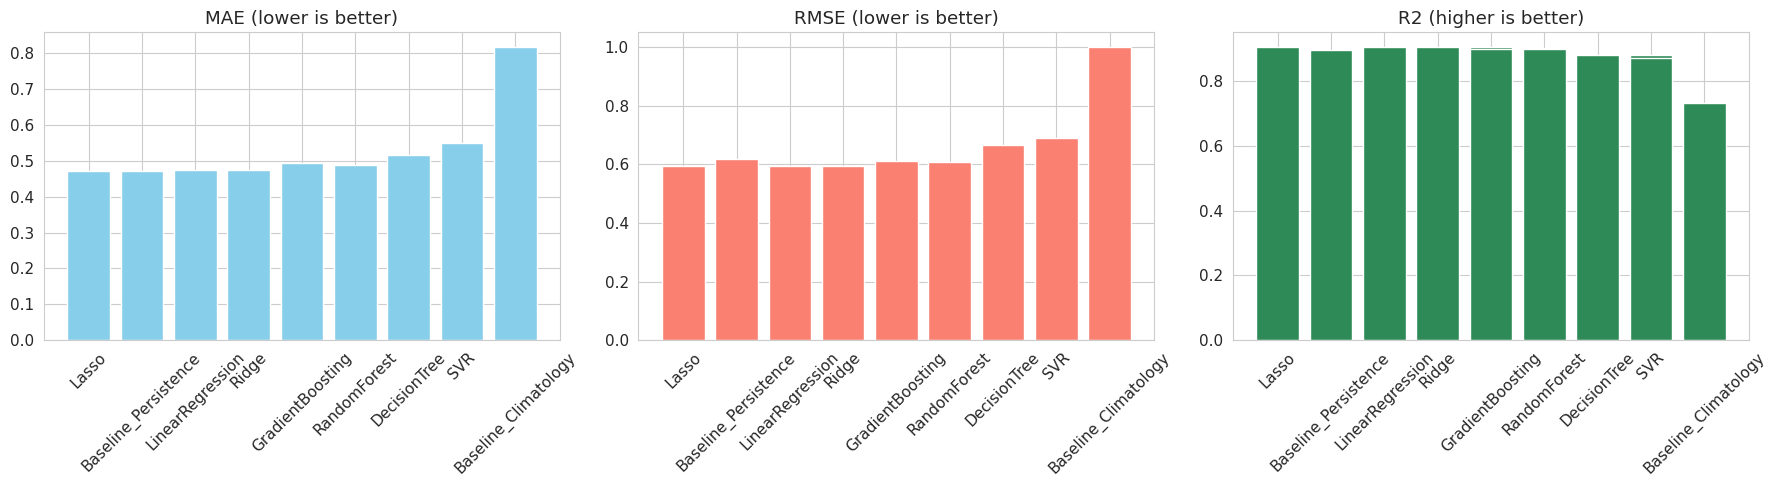

In [15]:
# Combine baselines, base models, and tuned models into one summary table
baseline_rows = [
    {'Model': 'Baseline_Persistence', **baseline_persist},
    {'Model': 'Baseline_Climatology', **baseline_clima},
 ]

base_rows = results_df.to_dict('records')
tuned_rows = tuned_df.drop(columns=['BestParams']).to_dict('records')

summary_df = pd.DataFrame(baseline_rows + base_rows + tuned_rows)
summary_df = summary_df.sort_values('MAE')
display(summary_df)

# Bar charts for MAE/RMSE/R2
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = summary_df['Model'].tolist()
mae = summary_df['MAE'].tolist()
rmse = summary_df['RMSE'].tolist()
r2 = summary_df['R2'].tolist()

axes[0].bar(labels, mae, color='skyblue')
axes[0].set_title('MAE (lower is better)')
axes[0].tick_params(axis='x', rotation=45)
axes[1].bar(labels, rmse, color='salmon')
axes[1].set_title('RMSE (lower is better)')
axes[1].tick_params(axis='x', rotation=45)
axes[2].bar(labels, r2, color='seagreen')
axes[2].set_title('R2 (higher is better)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../visuals/model_metrics_compare.png', dpi=300, bbox_inches='tight')
plt.show()

## 6) Error Analysis Preview

We preview residual behavior to ensure errors are random (no systematic bias).
Full analysis is in Notebook 07, but a quick check here supports reportability.

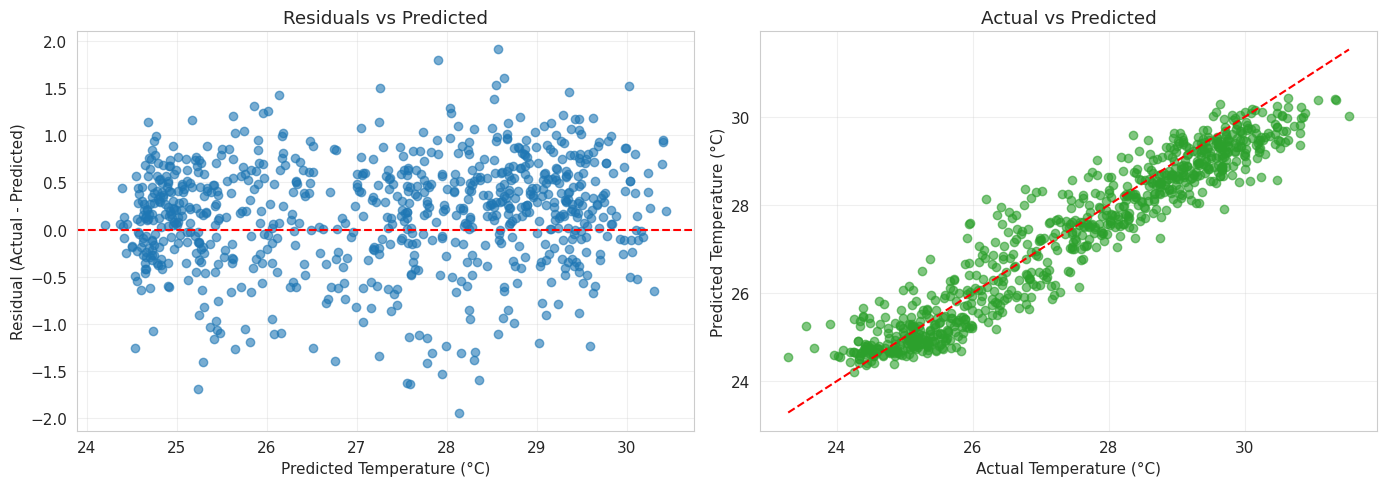

In [17]:
# Residual analysis preview for best tuned model
best_preds = best_model.predict(X_test)
residuals = y_test.values - best_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(best_preds, residuals, alpha=0.6, color='#1f77b4')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Temperature (°C)')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted')
axes[0].grid(alpha=0.3)

# Actual vs Predicted
axes[1].scatter(y_test, best_preds, alpha=0.6, color='#2ca02c')
min_val = min(y_test.min(), best_preds.min())
max_val = max(y_test.max(), best_preds.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[1].set_xlabel('Actual Temperature (°C)')
axes[1].set_ylabel('Predicted Temperature (°C)')
axes[1].set_title('Actual vs Predicted')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visuals/model_training_residuals_preview.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
# Save best model + metrics report (JSON)
best_model_path = MODELS_DIR / f"best_model_{best_model_name}.joblib"
joblib.dump(best_model, best_model_path)

report = {
    'best_model': best_model_name,
    'best_model_path': str(best_model_path),
    'baseline_metrics': {
        'persistence': baseline_persist,
        'climatology': baseline_clima,
    },
    'test_metrics_base_models': results_df.to_dict('records'),
    'test_metrics_tuned_models': tuned_df.to_dict('records'),
    'cross_validation': cv_df.to_dict('records'),
}

report_path = REPORTS_DIR / 'model_training_metrics.json'
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2)

print(f"Saved best model → {best_model_path}")
print(f"Saved metrics report → {report_path}")

Saved best model → ../models/saved_models/best_model_GradientBoosting.joblib
Saved metrics report → ../reports/model_training_metrics.json
